# 05 경보·오탐미탐 평가


## 실행 준비

In [1]:
from pathlib import Path
import sys
sys.dont_write_bytecode = True
working_dir = Path.cwd().resolve()
root = working_dir if (working_dir/'src'/'paths.py').is_file() else working_dir.parent
sys.path.insert(0,str(root/'src'))
from IPython.display import display, Image


## 고장 탐지 여부와 경보 횟수 확인

같은 고장 사건을 탐지한 모델끼리 첫 경보가 고장 시작보다 얼마나 일찍 나왔는지 비교한다. 놓친 사건은 빈 값으로 남긴다.

하루 평균 경보 수를 계산할 때는 전체 평가 기간의 날짜 수와 실제로 이상 점수가 기록된 날짜 수를 구분한다.

경보를 보낼지 먼저 결정한 뒤, 그 경보가 정상 구간에서 나왔는지 고장 전 구간에서 나왔는지 정답 기록과 비교해 분류한다.

In [2]:
from preprocess import load_cycles, load_splits, load_episodes
from time_series import load_signal_statistics
from data_checks import read_sensor
from modeling import load_model_bundle, load_predictions
from alarm_analysis import summarize_predictions, first_alert_comparisons, notification_burden, event_cycle_composition, boundary_sensitivity, output_paths
f=load_cycles()
splits=load_splits(f)
episodes=load_episodes()
feat=load_signal_statistics(f)
p=load_predictions(f)
bundle=load_model_bundle()
summary=summarize_predictions(p,episodes)
leads=first_alert_comparisons(p,summary['events'])
alarms=notification_burden(p,episodes,summary['metrics'],leads['lead'])
composition=event_cycle_composition(p)
display(leads['summary'].round(3))
display(alarms['burden'])
display(alarms['daily_stats'].round(2))

,period,model_a,model_b,common_detected,a_total_detected,b_total_detected,median_a_minus_b_hours,a_earlier,b_earlier,same_time
0,validation,ZScore,IF,6,7,7,2.183,3,1,2
1,validation,ZScore,LOF,6,7,7,0.561,4,2,0
2,validation,IF,LOF,6,7,7,0.508,3,2,1
3,July,ZScore,IF,2,2,2,4.546,2,0,0
4,July,ZScore,LOF,0,2,0,NaN,0,0,0
5,July,IF,LOF,0,2,0,NaN,0,0,0


,period,method,all_notifications,early,background,late,failure,recovery,unknown,first_signal_notifications,repeat_signal_notifications,suppressed_positive_cycles,early_event_repeats
0,validation,ZScore,214,39,164,4,5,2,0,186,28,202,32
1,validation,IF,62,18,36,2,5,1,0,62,0,28,11
2,validation,LOF,79,15,57,1,5,1,0,79,0,14,8
3,July,ZScore,174,27,134,2,2,3,6,147,27,234,25
4,July,IF,61,20,35,2,2,1,1,48,13,131,18
5,July,LOF,35,0,29,1,2,1,2,35,0,8,0


,period,method,calendar_days,observed_score_days,mean_calendar_day,median_calendar_day,p90_calendar_day,p95_calendar_day,max_calendar_day,max_dates,mean_observed_day,zero_notification_days
0,validation,ZScore,61,54,3.51,3.0,10.0,12.0,18,2020-06-18,3.96,20
1,validation,IF,61,54,1.02,0.0,4.0,5.0,7,2020-05-22,1.15,36
2,validation,LOF,61,54,1.30,1.0,4.0,5.0,5,2020-05-16|2020-05-18|2020-05-23|2020-06-12,1.46,22
3,July,ZScore,31,31,5.61,6.0,9.0,12.0,18,2020-07-15,5.61,3
4,July,IF,31,31,1.97,1.0,4.0,6.5,14,2020-07-15,1.97,11
5,July,LOF,31,31,1.13,1.0,3.0,3.0,4,2020-07-21,1.13,11


In [3]:
from plot_alarms import plot_first_alerts, plot_daily_alarms, plot_case_signals, plot_case_profiles
plot_first_alerts(leads['lead'])
plot_daily_alarms(alarms['daily'])

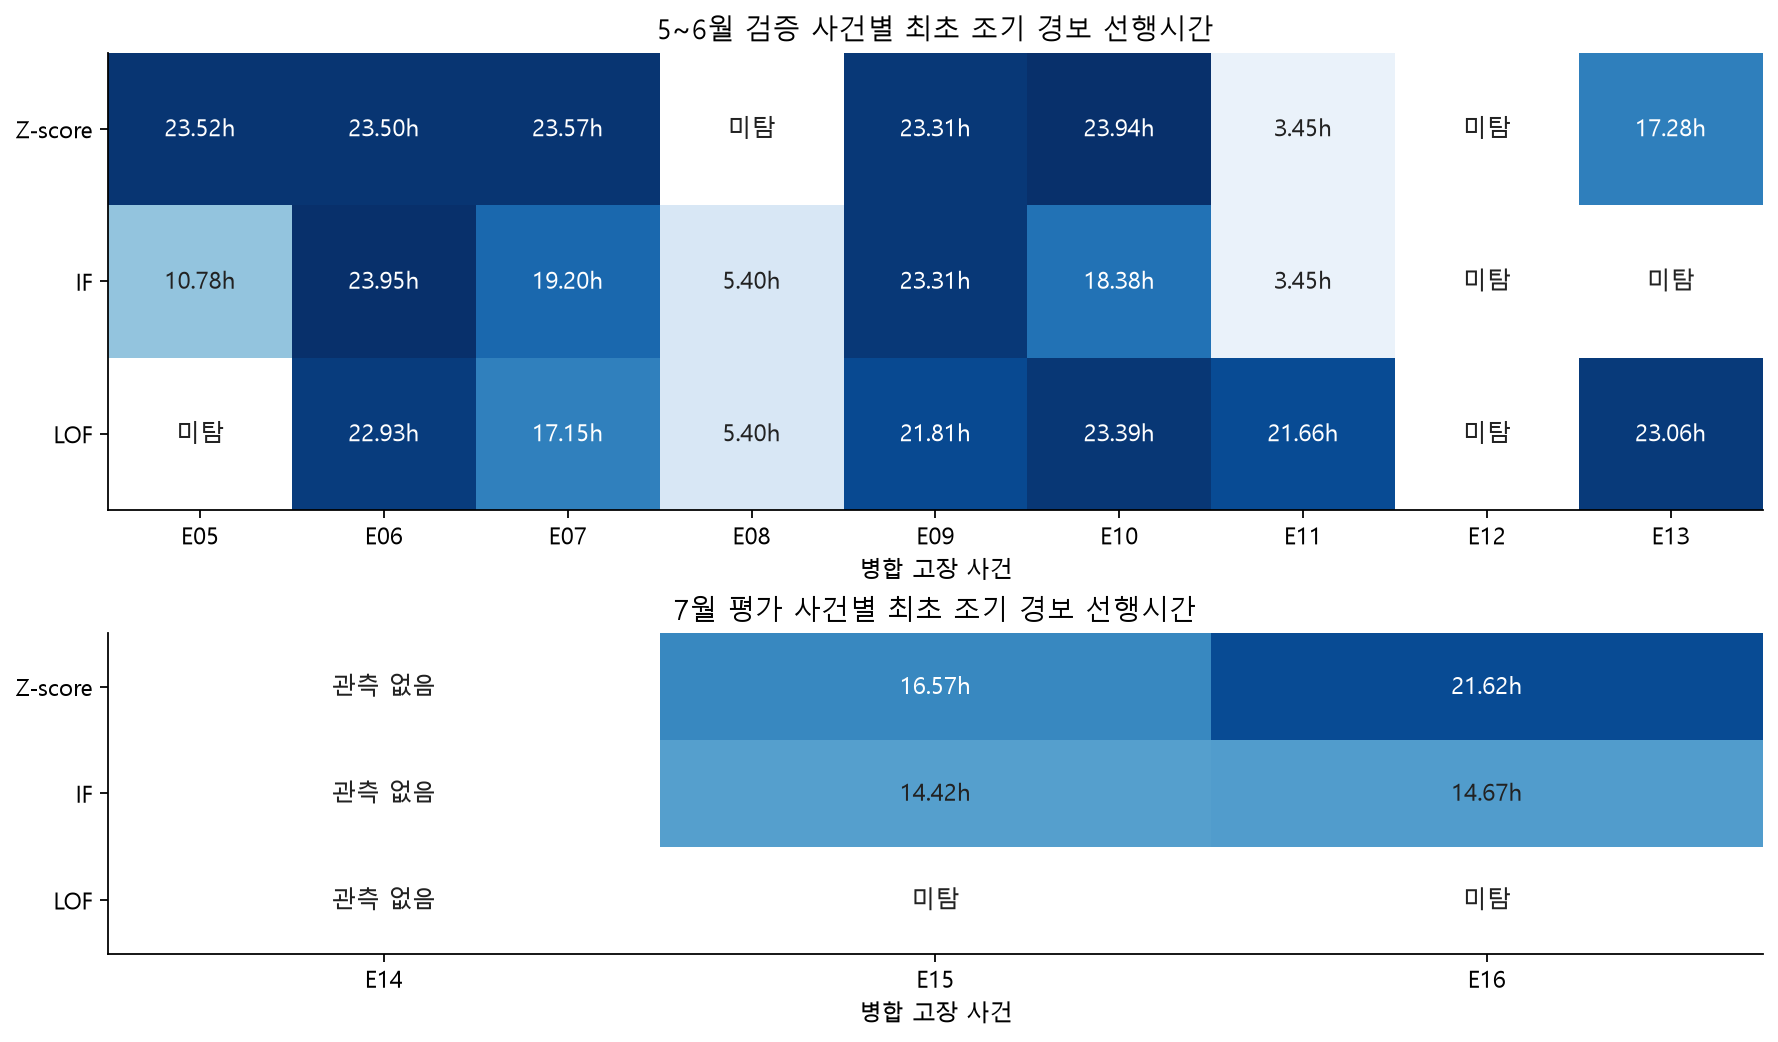

In [4]:
display(Image(filename=str(output_paths()['figure07'])))

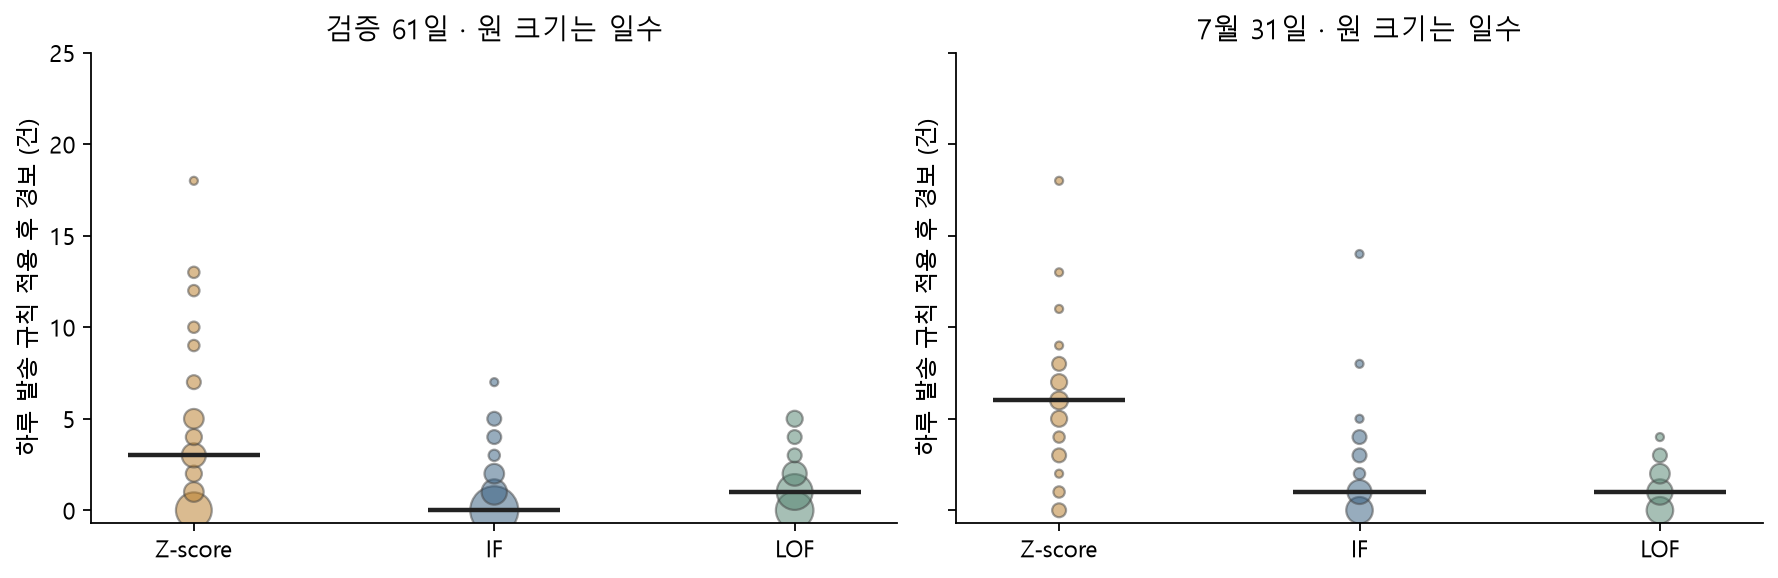

In [5]:
display(Image(filename=str(output_paths()['figure08'])))

## 잘못 판단한 사례와 운전 조건이 비슷한 사례 비교

다음 두 가지를 비교한다.
- LOF: 정상인데 경보를 보낸 주기와, 정상으로 올바르게 판단한 주기
- IF: 고장 전인데 놓친 주기와, 같은 고장 사건에서 이상을 올바르게 잡아낸 주기

잘못 판단한 주기를 시간순으로 살펴보며, 아래 조건을 모두 만족하는 비교 사례를 찾는다.
- 두 주기의 시각 차이가 24시간 이내
- 두 주기의 길이 비율이 0.8~1.25배
- 전체 주기에서 가동 시간이 차지하는 비율의 차이가 3%포인트 이내
- 가동 중 평균 전류 차이가 0.5A 이내
- 가동 중 평균 압력 차이가 0.3bar 이내
조건에 맞는 사례가 여러 개면 시각이 가장 가까운 것을 고르고, 시각 차이도 같으면 주기 번호 순으로 선택한다.

In [6]:
from case_analysis import error_feature_summary, match_error_cases, score_feature_associations, diagnose_cases
error_result=error_feature_summary(p,feat,summary['metrics'])
matched=match_error_cases(p,feat)
associations=score_feature_associations(matched['eligible_rows'])
raw=read_sensor()
train=f.loc[splits.train].reset_index(drop=True)
diagnostics=diagnose_cases(matched['cases'],raw,train,bundle)
display(matched['pairs'])
display(error_result['summary'].query("period == 'July'").head(24))
display(diagnostics['neighbor_summary'])
display(diagnostics['if_paths'])
plot_case_signals(matched['cases'],p,diagnostics['raw_windows'])
profile_values=plot_case_profiles(matched['cases'],feat,diagnostics['neighbors'])

,method,error_kind,error_id,control_id,time_gap_hours,duration_ratio,run_fraction_difference,current_run_mean_difference,pressure_run_mean_difference,eligible_controls
0,LOF,FP,cycle_1084198,cycle_1084070,0.344167,1.025020,-0.002935,-0.093667,-0.017333,95
1,IF,FN,cycle_1176908,cycle_1181759,13.520833,0.829843,0.026901,-0.072031,-0.022242,1


,period,method,outcome,feature,n,median,q25,q75,min,max,mean
96,July,ZScore,TN,pressure_cycle_mean,1433,9.037748,9.004662,9.072143,8.047290,9.412419,9.041133
97,July,ZScore,TN,current_cycle_mean,1433,2.021208,1.827320,2.336917,1.295058,3.354470,2.098384
98,July,ZScore,TN,pressure_run_mean,1433,9.133429,9.093250,9.172000,6.739918,10.142000,9.134092
99,July,ZScore,TN,pressure_idle_mean,1433,9.024252,8.993063,9.059190,8.776933,9.458889,9.030297
100,July,ZScore,TN,current_run_mean,1433,5.882000,5.844333,5.919583,1.919856,6.198750,5.870184
101,July,ZScore,TN,current_idle_mean,1433,1.496333,1.360086,1.764258,1.082257,2.389036,1.573658
102,July,ZScore,TN,cycle_minutes,1433,19.816667,17.183333,21.483333,13.716667,27.916667,19.420656
103,July,ZScore,TN,run_fraction,1433,0.117897,0.103886,0.140673,0.015516,0.432239,0.124046
104,July,ZScore,FP,pressure_cycle_mean,230,9.086362,9.033566,9.177957,7.216133,10.042000,9.096230
105,July,ZScore,FP,current_cycle_mean,230,3.133497,3.002919,3.396236,0.037500,5.430938,3.236207


,role,cycle_id,score,threshold,mean_distance,mean_reachability_distance,query_local_reachability_density,mean_neighbor_density,rebuilt_score
0,error,cycle_1084198,5.802919,2.015209,0.66014,0.712730,1.403057,8.141824,5.802919
1,control,cycle_1084070,1.003794,2.015209,0.08766,0.114427,8.739203,8.772358,1.003794


,role,cycle_id,score,threshold,mean_adjusted_path_length,path_q25,path_q75,rebuilt_score
0,error,cycle_1176908,0.520255,0.535155,9.657834,8.0,11.535537,0.520255
1,control,cycle_1181759,0.557294,0.535155,8.641354,7.0,10.327020,0.557294


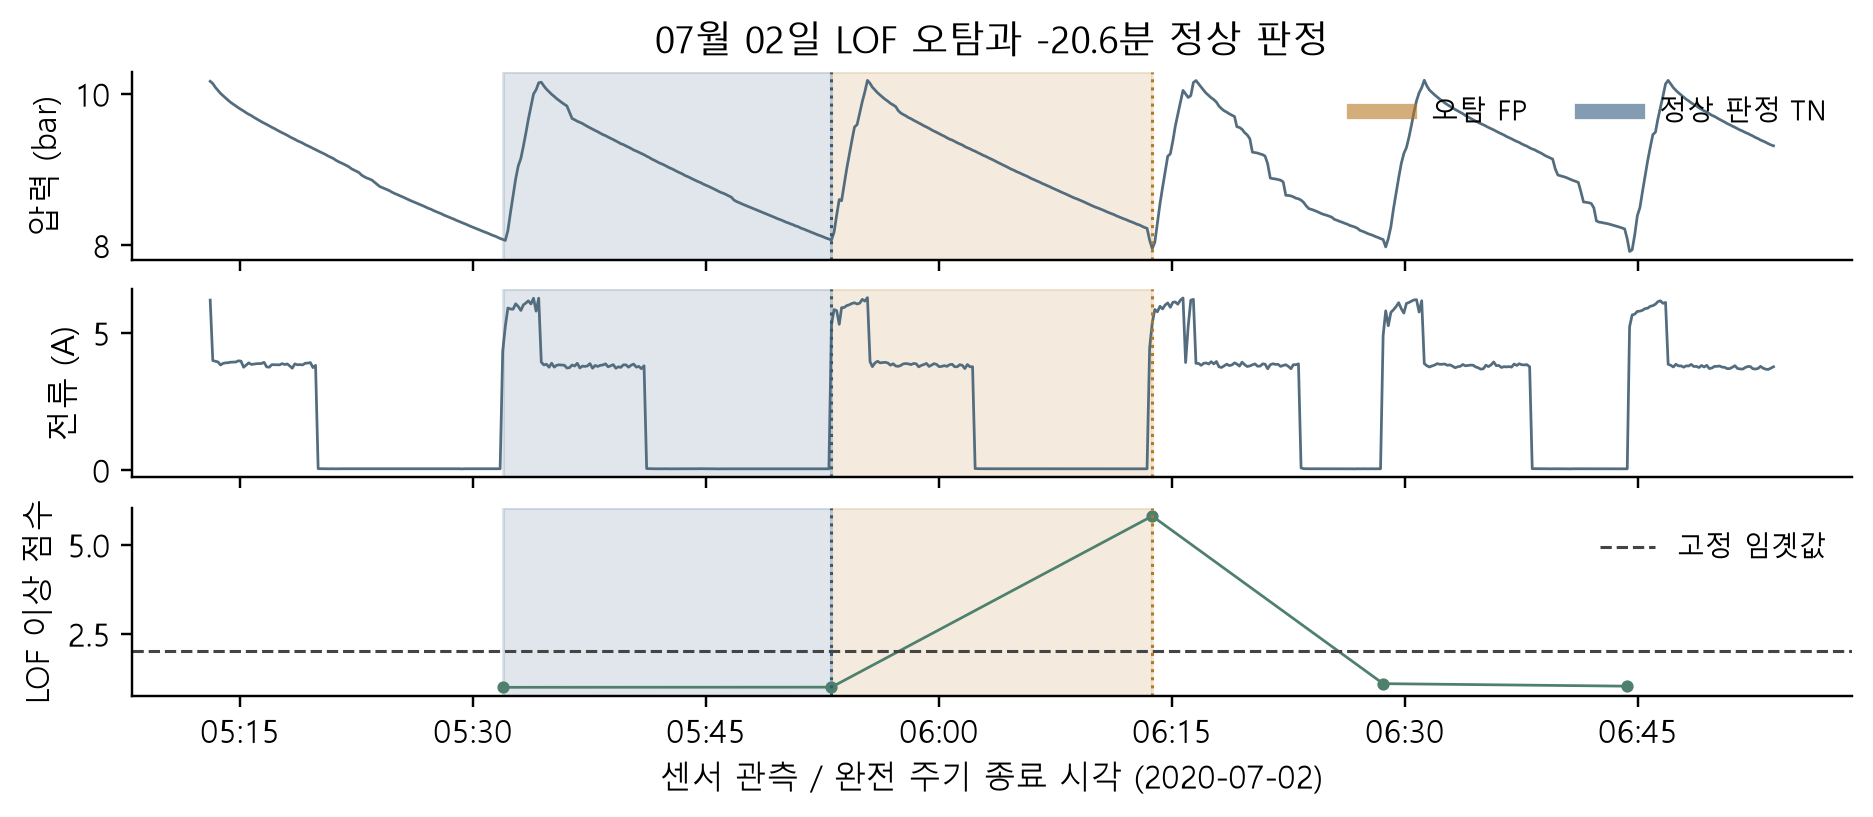

In [7]:
display(Image(filename=str(output_paths()['figure09'])))

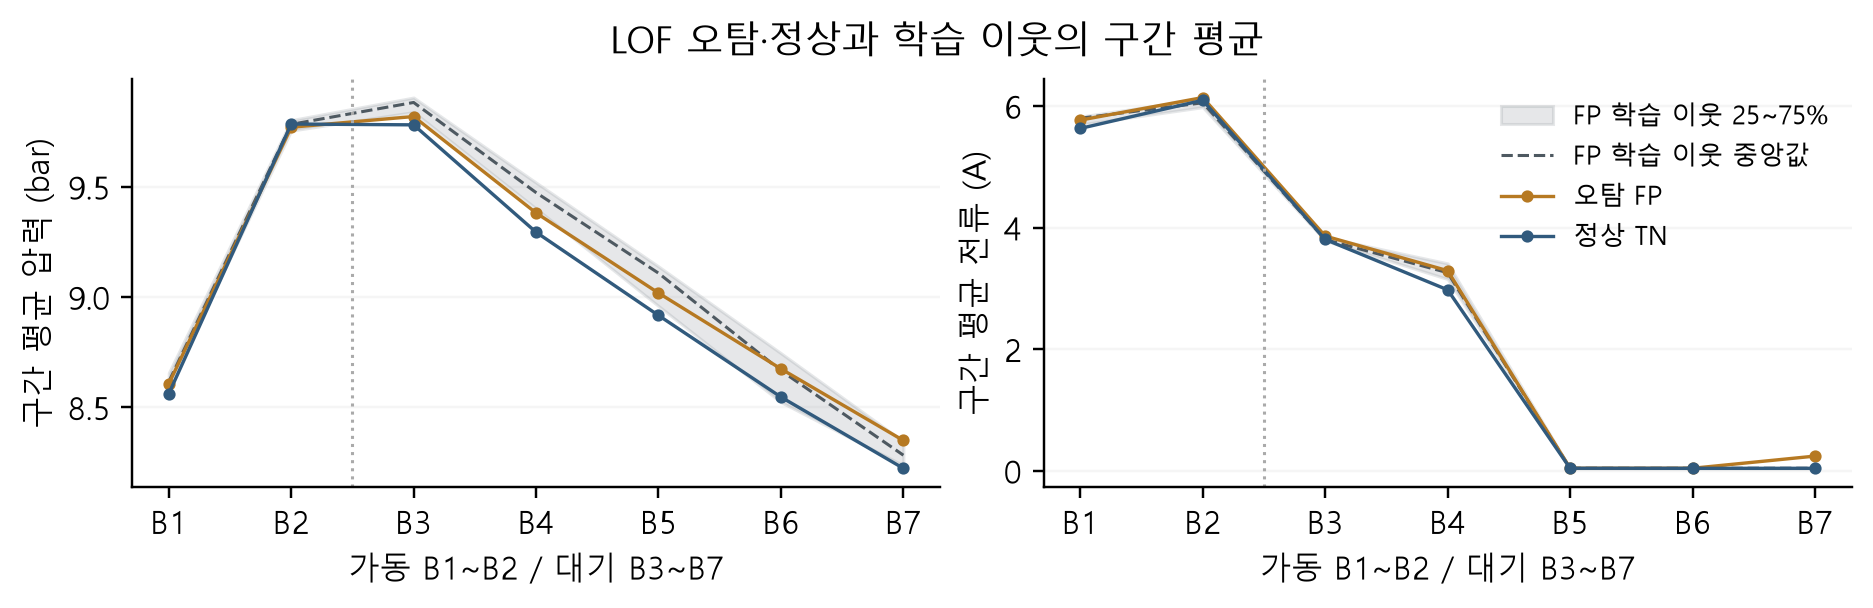

In [8]:
display(Image(filename=str(output_paths()['figure10'])))

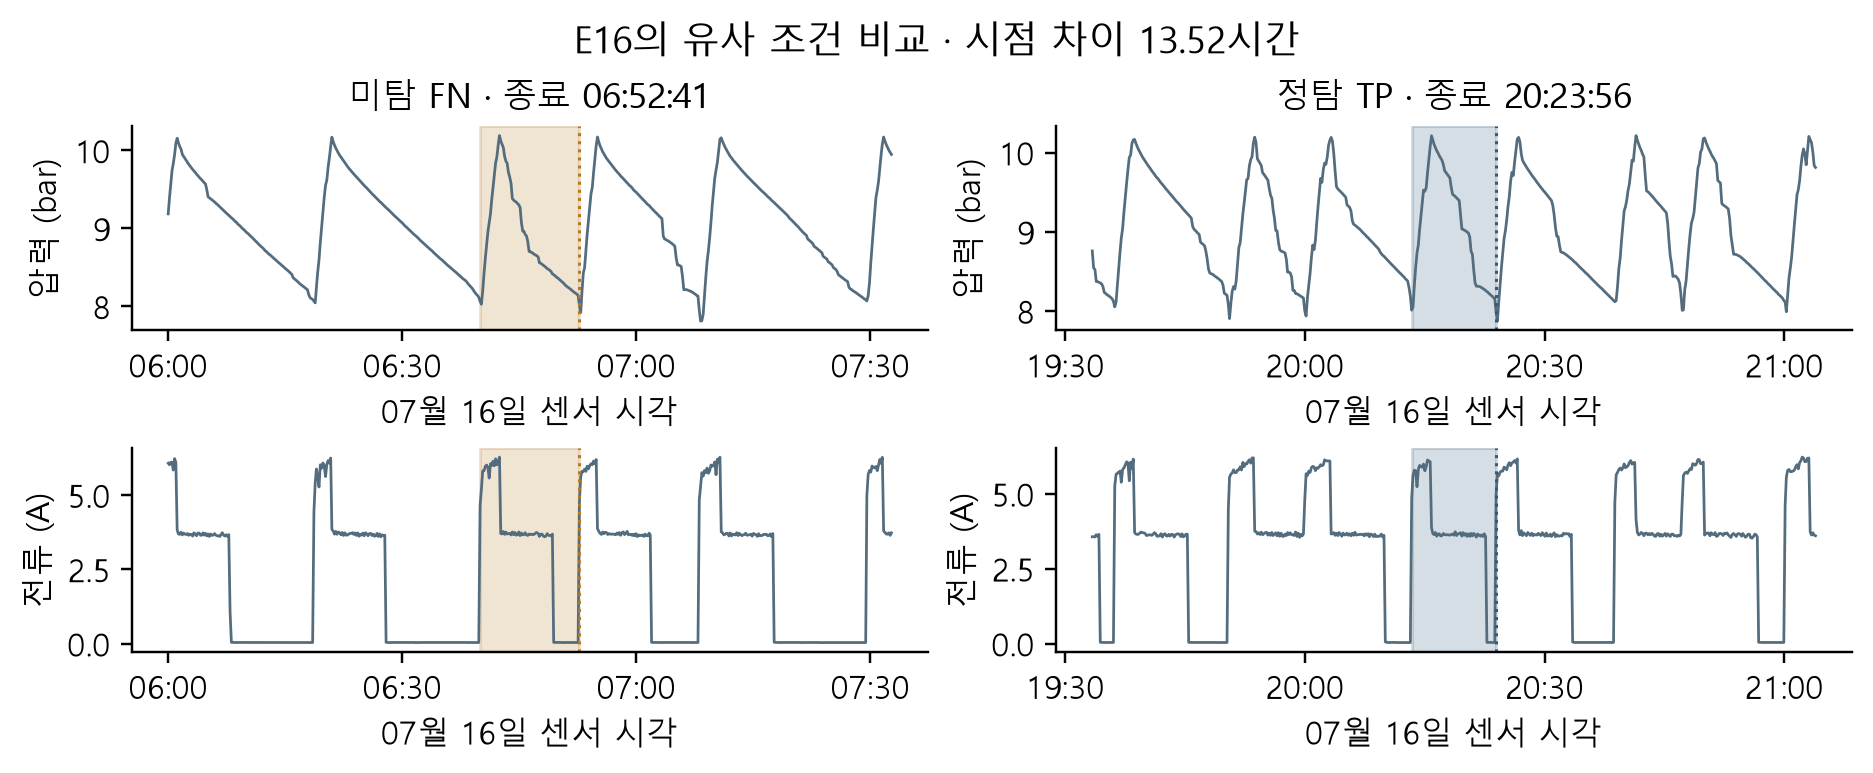

In [9]:
display(Image(filename=str(output_paths()['figure11'])))

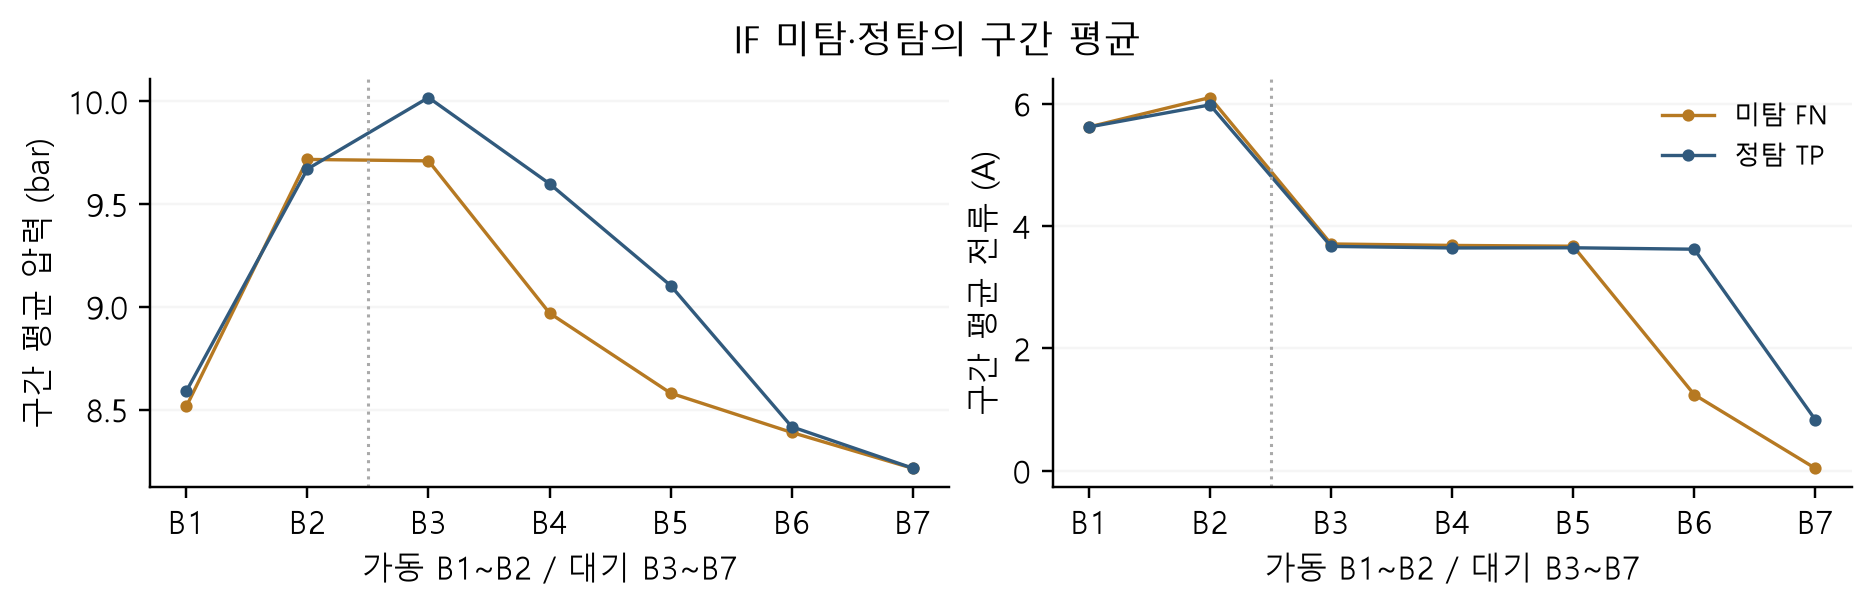

In [10]:
display(Image(filename=str(output_paths()['figure12'])))

## 평가 시작 시 경보 처리와 모델 판단 살펴보기

월이 바뀔 때 경보를 처리하는 두 방법을 비교한다.
- 이전 달 마지막 경보의 1시간 대기 규칙을 다음 달에도 이어서 적용하는 방법
- 평가 시작 시 이전 경보 기록을 초기화하고 새로 시작하는 방법

LOF가 어떤 자료와 비교해 이상으로 판단했는지 확인할 때는 3~4월 학습 주기만 비교 대상으로 사용한다.

IF는 각 나무에서 해당 주기를 따로 구분하기까지 거친 단계 수를 바탕으로 이상 점수를 다시 계산해 확인한다.

압력·전류의 패턴이나 시간 관련 값을 서로 바꿔 넣은 예시도 살펴본다.

In [11]:
boundary=boundary_sensitivity(f,splits,episodes,p,bundle)
display(boundary)
display(composition['event_recall'])
display(composition['composition'])
display(diagnostics['if_swaps'])
display(diagnostics['if_decomposition'])

,method,different_notification_rows,carried_false_alerts,carried_events_detected
0,ZScore,0,134,2
1,IF,0,35,2
2,LOF,0,29,0


,method,episode,positive_cycles,TP,FN,cycle_recall,early_notifications,repeat_after_first
0,IF,episode_15,101,91,10,0.900990,12,11
1,IF,episode_16,81,27,54,0.333333,8,7
2,LOF,episode_15,101,0,101,0.000000,0,0
3,LOF,episode_16,81,0,81,0.000000,0,0
4,ZScore,episode_15,101,101,0,1.000000,14,13
5,ZScore,episode_16,81,43,38,0.530864,13,12


,method,all_notifications,background_false_notifications,false_share_of_all,early_notifications,repeat_early_after_first,repeat_share_of_early
0,IF,61,35,0.573770,20,18,0.900000
1,LOF,35,29,0.828571,0,0,NaN
2,ZScore,174,134,0.770115,27,25,0.925926


,sensor_profile_from,timing_from,IF_score,threshold,interpretation
0,FN,FN,0.520255,0.535155,"constructed pairwise sensitivity, not observed..."
1,FN,TP,0.552493,0.535155,"constructed pairwise sensitivity, not observed..."
2,TP,FN,0.567478,0.535155,"constructed pairwise sensitivity, not observed..."
3,TP,TP,0.557294,0.535155,"constructed pairwise sensitivity, not observed..."


{'profile_score_change': 0.0260120055556618,
 'timing_score_change': 0.011026907367364835,
 'total_observed_score_change': np.float64(0.037038912923026635),
 'not_causal': True}